### IMPORT AND DEPENDENCIES

In [1]:
import os
import re
import json
import time
import unicodedata
import pandas as pd
import numpy as np 
from openai import OpenAI
import difflib
import matplotlib.pyplot as plt
import seaborn as sns  
import matplotlib.dates as mdates

### CONFIGURATION

In [ ]:
client = OpenAI(api_key="")
MODEL = "gpt-4.1-nano"

JOB_LOG = "./BATCH/batch_jobs.json"
BATCH_DIR = "./BATCH"

ENQUEUED_TOKEN_LIMIT = 2_000_000
SAFETY_MARGIN = 0.9  # leave 10% headroom


df = pd.read_csv("./../results/immigration_speeches_short.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.reset_index(drop=True)
df["speech_id"] = df.index
df["Party"] = df["Party"].fillna("Cabinet/Unknown")
df["date"] = pd.to_datetime(df["date"])

df = df[df["is_immigration"] == True].copy()
print(f"{len(df)} immigration-related speeches after filtering")

28662 immigration-related speeches after filtering


### FUNCTIONS

#### MIGRATION STANCE CLASSIFICATION 

In [ ]:
SOLIDARITY_SUBTYPES = {
    "group-based":
        "Migrants are recognized as a legitimate group with equal rights, "
        "interests, or claims.",

    "exchange-based":
        "Support is based on reciprocity: an individual migrant contributes "
        "or fulfills obligations and therefore deserves support or rights.",

    "economic-utility":
        "Migration is presented as beneficial or necessary for the German "
        "economy or society, e.g. labor shortages, demographics, growth, "
        "taxes, or skilled labor.",

    "compassionate":
        "Migrants/refugees are portrayed as vulnerable or suffering and "
        "therefore deserving protection, sympathy, or support.",

    "empathic":
        "Migrants' identity, dignity, culture, autonomy, or self-determination "
        "is explicitly recognized or respected."
}

ANTISOLIDARITY_SUBTYPES = {
    "group-based":
        "Migrants are portrayed as an out-group or as having fewer rights "
        "than natives; native interests are prioritized.",

    "exchange-based":
        "An individual migrant is portrayed as taking more than they "
        "contribute or failing to fulfill obligations.",

    "economic-burden":
        "Migration is presented as economically harmful or costly, e.g. "
        "welfare costs, fiscal burden, wage competition, or pressure on resources.",

    "compassionate":
        "Migrants' need for protection or humanitarian support is dismissed "
        "or portrayed as undeserving.",

    "empathic":
        "Migrants' identity, dignity, culture, autonomy, or self-determination "
        "is denied or rejected."
}


def build_prompt(text: str) -> str:

    sol = "\n".join(
        f"- {k.upper()}: {v}"
        for k, v in SOLIDARITY_SUBTYPES.items()
    )

    anti = "\n".join(
        f"- {k.upper()}: {v}"
        for k, v in ANTISOLIDARITY_SUBTYPES.items()
    )

    return f"""
Classify the following German parliamentary speech excerpt according to its
stance toward migrants, refugees, asylum seekers, or immigrants.

LABELS
------
SOLIDARITY = supportive, accepting, protective, inclusive, or sympathetic.
ANTI-SOLIDARITY = opposing, excluding, rejecting, hostile, or unwilling to support.
MIXED = both meaningful solidarity and anti-solidarity.
NONE = no clear stance toward migrants.

RULES
-----
- Migration must be the target. Mentioning migration alone is not enough.
- Neutral facts, statistics, questions, or policy descriptions = NONE.
- Criticism/support of government or migration policy is not automatically
  anti/pro-migration; classify only the stance toward migrants.
- Do not classify unrelated groups or historical German expellees as migrants.
- If the evidence is unclear, choose NONE.
- If SOLIDARITY or ANTI-SOLIDARITY, choose exactly ONE subtype.
- If MIXED or NONE, subtype = NONE.

SOLIDARITY SUBTYPES
-------------------
{sol}

ANTI-SOLIDARITY SUBTYPES
------------------------
{anti}

TEXT
----
**{text}**

OUTPUT FORMAT
-------------

Return EXACTLY two lines and nothing else:

Justification: <one short sentence explaining the decision>
Label: <HIGH-LEVEL>[-<SUBTYPE>]

VALID LABELS
------------

SOLIDARITY-GROUP-BASED
SOLIDARITY-EXCHANGE-BASED
SOLIDARITY-ECONOMIC-UTILITY
SOLIDARITY-COMPASSIONATE
SOLIDARITY-EMPATHIC

ANTI-SOLIDARITY-GROUP-BASED
ANTI-SOLIDARITY-EXCHANGE-BASED
ANTI-SOLIDARITY-ECONOMIC-BURDEN
ANTI-SOLIDARITY-COMPASSIONATE
ANTI-SOLIDARITY-EMPATHIC

MIXED
NONE
""".strip()

In [6]:
MIGRATION_KEYWORDS = [
    "migration", "zuwander", "einwander", "asyl", "flüchtling",
    "geflüchtet", "schutzsuchend", "ausländ", "vertrieben",
    "migrant", "aussiedler", "ansiedler", "bürgerkriegs",
]

def fix_hyphenation_artifacts(text: str) -> str:
    """Repairs likely line-break hyphenation artifacts from digitized text,
    e.g. 'die.\nsen' -> 'diesen', where a short fragment ending in '.'/'-'
    is followed by a lowercase continuation (heuristic — spot-check results)."""
    if not isinstance(text, str):
        return text
    return re.sub(r'(\b\w{1,4})[\.\-]\s*\n?\s*([a-zäöüß]{2,})', r'\1\2', text)

def split_sentences(text: str) -> list[str]:
    if not isinstance(text, str):
        return []
    text = unicodedata.normalize("NFC", text)
    text = fix_hyphenation_artifacts(text)
    return [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]

def extract_target_snippets(text: str, window: int = 3) -> list[str]:
    sentences = split_sentences(text)
    lowered = [s.lower() for s in sentences]
    snippets = []
    for i, s in enumerate(lowered):
        if any(kw in s for kw in MIGRATION_KEYWORDS):
            start = max(0, i - window)
            end = min(len(sentences), i + window + 1)
            context = sentences[start:end]
            marked = context.copy()
            marked[i - start] = f"**{marked[i - start]}**"
            snippets.append(" ".join(marked))
    return snippets

records = []
for _, row in df.iterrows():
    for snippet in extract_target_snippets(row["text"]):
        records.append({
            "speech_id": row["speech_id"],
            "date": row["date"],
            "party": row["Party"],
            "role": row["Role"],
            "governing_party": row["governing_Party"],
            "text": snippet,
        })

snippets_df = pd.DataFrame(records)
print(f"{len(snippets_df)} target snippets extracted from {len(df)} speeches")

snippets_df.to_csv("./DATA/snippets_df.csv", index=False)

95452 target snippets extracted from 28662 speeches


In [57]:
def build_batch_file(chunk_df: pd.DataFrame, out_path: str):
    with open(out_path, "w", encoding="utf-8") as f:
        for idx, row in chunk_df.iterrows():
            request = {
                "custom_id": f"{row['speech_id']}_{idx}",
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": {
                    "model": MODEL,
                    "messages": [{"role": "user", "content": build_prompt(row["text"])}],
                    "temperature": 0,
                    "max_tokens": 150,
                },
            }
            f.write(json.dumps(request) + "\n")

def wait_for_batch(batch_id: str, poll_seconds: int = 60):
    while True:
        job = client.batches.retrieve(batch_id)
        print(f"  [{batch_id}] status={job.status} "
              f"completed={job.request_counts.completed}/{job.request_counts.total} "
              f"failed={job.request_counts.failed}")
        if job.status in ("completed", "failed", "expired", "cancelled"):
            return job
        time.sleep(poll_seconds)

In [58]:
def estimate_cost(sample_size: int = 50) -> dict:
    sample = snippets_df.sample(n=sample_size, random_state=1).reset_index(drop=True)
    build_batch_file(sample, out_path="pilot_batch.jsonl")

    batch_file = client.files.create(file=open("pilot_batch.jsonl", "rb"), purpose="batch")
    job = client.batches.create(input_file_id=batch_file.id,
                                  endpoint="/v1/chat/completions",
                                  completion_window="24h")
    print(f"Pilot batch submitted: {job.id} — waiting for completion...")
    job = wait_for_batch(job.id, poll_seconds=30)

    if job.status != "completed":
        print(f"Pilot did not complete: {job.status}")
        if job.error_file_id:
            print(client.files.content(job.error_file_id).text[:2000])
        return {}

    result_file = client.files.content(job.output_file_id)
    total_input, total_output = 0, 0
    for line in result_file.text.splitlines():
        rec = json.loads(line)
        usage = rec["response"]["body"].get("usage", {})
        total_input += usage.get("prompt_tokens", 0)
        total_output += usage.get("completion_tokens", 0)

    avg_input = total_input / sample_size
    avg_output = total_output / sample_size
    avg_total = avg_input + avg_output

    # verify current rate at platform.openai.com/docs/pricing before trusting this
    input_price_per_1m = 0.10 * 0.5   # batch = 50% off
    output_price_per_1m = 0.40 * 0.5

    full_n = len(snippets_df)
    est_total_cost = ((avg_input * full_n / 1_000_000) * input_price_per_1m
                       + (avg_output * full_n / 1_000_000) * output_price_per_1m)

    print(f"Avg tokens/snippet — input: {avg_input:.0f}, output: {avg_output:.0f}, total: {avg_total:.0f}")
    print(f"Estimated cost for full {full_n} snippets: ${est_total_cost:.2f}")
    return {"avg_input": avg_input, "avg_output": avg_output,
            "avg_total": avg_total, "est_total_usd": est_total_cost}

In [60]:
def load_job_log() -> dict:
    return json.load(open(JOB_LOG)) if os.path.exists(JOB_LOG) else {}

def save_job_log(log: dict):
    json.dump(log, open(JOB_LOG, "w"), indent=2)

def submit_chunks_sequentially(chunks: list[pd.DataFrame], max_retries: int = 10):
    log = load_job_log()
    for i, chunk in enumerate(chunks):
        chunk_key = f"chunk_{i}"
        if chunk_key in log and log[chunk_key].get("status") == "completed":
            print(f"{chunk_key} already completed, skipping.")
            continue

        attempt = 0
        while attempt <= max_retries:
            batch_path = f"{BATCH_DIR}/batch_input_{i}.jsonl"
            build_batch_file(chunk, batch_path)
            batch_file = client.files.create(file=open(batch_path, "rb"), purpose="batch")

            while True:
                try:
                    job = client.batches.create(
                        input_file_id=batch_file.id,
                        endpoint="/v1/chat/completions",
                        completion_window="24h",
                    )
                    break
                except Exception as e:
                    if "token_limit_exceeded" in str(e):
                        print(f"{chunk_key}: queue full at submit time, waiting 5 min...")
                        time.sleep(300)
                    else:
                        raise

            print(f"Submitted {chunk_key}: job_id={job.id} ({len(chunk)} snippets)")
            log[chunk_key] = {"job_id": job.id, "status": "submitted", "size": len(chunk)}
            save_job_log(log)

            job = wait_for_batch(job.id, poll_seconds=60)
            log[chunk_key]["status"] = job.status

            if job.status == "completed":
                log[chunk_key]["output_file_id"] = job.output_file_id
                save_job_log(log)
                break  # success, move to next chunk

            # Failed — check WHY before giving up
            error_codes = [e.code for e in (job.errors.data if job.errors else [])]
            log[chunk_key]["error_file_id"] = job.error_file_id
            save_job_log(log)

            if "token_limit_exceeded" in error_codes and attempt < max_retries:
                attempt += 1
                print(f"  {chunk_key}: enqueued token limit hit post-validation "
                      f"(attempt {attempt}/{max_retries}), waiting 5 min before retry...")
                time.sleep(300)
                continue  # rebuild + resubmit same chunk
            else:
                print(f"  WARNING: {chunk_key} ended with status {job.status} "
                      f"(codes: {error_codes})")
                break


In [ ]:
def chunk_dataframe(chunk_df: pd.DataFrame, chunk_size: int) -> list[pd.DataFrame]:
    return [chunk_df.iloc[i:i + chunk_size].reset_index(drop=True)
            for i in range(0, len(chunk_df), chunk_size)]

### ESTIMATION

In [ ]:
estimate = estimate_cost(sample_size=50)

Pilot batch submitted: batch_6aa0137bbddc8190a75aa7e31baee72b — waiting for completion...
  [batch_6aa0137bbddc8190a75aa7e31baee72b] status=validating completed=0/0 failed=0
  [batch_6aa0137bbddc8190a75aa7e31baee72b] status=validating completed=0/0 failed=0
  [batch_6aa0137bbddc8190a75aa7e31baee72b] status=validating completed=0/0 failed=0
  [batch_6aa0137bbddc8190a75aa7e31baee72b] status=in_progress completed=46/50 failed=0
  [batch_6aa0137bbddc8190a75aa7e31baee72b] status=in_progress completed=46/50 failed=0
  [batch_6aa0137bbddc8190a75aa7e31baee72b] status=in_progress completed=46/50 failed=0
  [batch_6aa0137bbddc8190a75aa7e31baee72b] status=in_progress completed=46/50 failed=0
  [batch_6aa0137bbddc8190a75aa7e31baee72b] status=completed completed=50/50 failed=0
Avg tokens/snippet — input: 881, output: 38, total: 918
Estimated cost for full 95452 snippets: $4.92


In [ ]:
safe_chunk_size = int((ENQUEUED_TOKEN_LIMIT * SAFETY_MARGIN) / estimate["avg_total"])
print(f"Safe chunk size given {estimate['avg_total']:.0f} tokens/snippet: {safe_chunk_size} snippets/chunk")

chunks = chunk_dataframe(snippets_df, chunk_size=safe_chunk_size)
print(f"Split into {len(chunks)} chunks")

Safe chunk size given 918 tokens/snippet: 1960 snippets/chunk
Split into 49 chunks


In [ ]:
submit_chunks_sequentially(chunks)

chunk_0 already completed, skipping.
chunk_1 already completed, skipping.
chunk_2 already completed, skipping.
chunk_3 already completed, skipping.
chunk_4 already completed, skipping.
chunk_5 already completed, skipping.
chunk_6 already completed, skipping.
chunk_7 already completed, skipping.
chunk_8 already completed, skipping.
chunk_9 already completed, skipping.
chunk_10 already completed, skipping.
Submitted chunk_11: job_id=batch_6aa01c0e4a48819087a7de03e219a27c (1960 snippets)
  [batch_6aa01c0e4a48819087a7de03e219a27c] status=validating completed=0/0 failed=0
  [batch_6aa01c0e4a48819087a7de03e219a27c] status=validating completed=0/0 failed=0
  [batch_6aa01c0e4a48819087a7de03e219a27c] status=in_progress completed=350/1960 failed=0
  [batch_6aa01c0e4a48819087a7de03e219a27c] status=in_progress completed=1930/1960 failed=0
  [batch_6aa01c0e4a48819087a7de03e219a27c] status=completed completed=1960/1960 failed=0
chunk_12 already completed, skipping.
chunk_13 already completed, skippi

### REGEX PATTERNS FOR PARSING OUTPUT

In [ ]:
_LABEL_RE = re.compile(r'Label\s*:\s*(.+)', re.IGNORECASE)
_JUSTIFICATION_RE = re.compile(r'Justification\s*:\s*(.+)', re.IGNORECASE)

_SUBTYPE_KEY_BY_UPPER = {
    k.upper(): k for k in set(SOLIDARITY_SUBTYPES) | set(ANTISOLIDARITY_SUBTYPES)
}
VALID_LABELS = (
    {f"SOLIDARITY-{k.upper()}" for k in SOLIDARITY_SUBTYPES}
    | {f"ANTI-SOLIDARITY-{k.upper()}" for k in ANTISOLIDARITY_SUBTYPES}
    | {"MIXED", "NONE"}
)

_BARE_HIGH_LEVEL = {"SOLIDARITY", "ANTI-SOLIDARITY"}

# Map a bare subtype (no high-level prefix) to the set of high-level
# categories it could belong to. Most subtype names are shared by both dicts
# (e.g. "group-based"), so those stay ambiguous on purpose. Only
# economic-utility / economic-burden are unique to one side.
_SUBTYPE_ONLY_TO_HIGH: dict[str, set[str]] = {}
for k in SOLIDARITY_SUBTYPES:
    _SUBTYPE_ONLY_TO_HIGH.setdefault(k.upper(), set()).add("SOLIDARITY")
for k in ANTISOLIDARITY_SUBTYPES:
    _SUBTYPE_ONLY_TO_HIGH.setdefault(k.upper(), set()).add("ANTI-SOLIDARITY")


def _normalize_raw_label(raw: str) -> str:
    raw = raw.strip().strip("*[]().:>").strip()
    raw = raw.upper()
    raw = raw.replace("SOLIDITY", "SOLIDARITY")  # common typo: "anti-solidity-..."
    # Strip the literal "HIGH-LEVEL" placeholder the model sometimes echoes
    # from the prompt's format spec, whatever separator follows it
    # (observed: "-", ">", ":", or nothing).
    raw = re.sub(r'^HIGH-LEVEL[\s\-:>]*', '', raw)
    raw = raw.strip("*[]().:> ").strip()
    return raw


def _resolve_label(raw_upper: str):
    """Returns (high_level, subtype_key, warning_or_None, hard_error_or_None)."""

    if raw_upper in VALID_LABELS:
        if raw_upper in ("MIXED", "NONE"):
            return raw_upper, None, None, None
        if raw_upper.startswith("ANTI-SOLIDARITY-"):
            sub = _SUBTYPE_KEY_BY_UPPER[raw_upper[len("ANTI-SOLIDARITY-"):]]
            return "ANTI-SOLIDARITY", sub, None, None
        sub = _SUBTYPE_KEY_BY_UPPER[raw_upper[len("SOLIDARITY-"):]]
        return "SOLIDARITY", sub, None, None

    # Bare high-level, subtype omitted entirely
    if raw_upper in _BARE_HIGH_LEVEL:
        return raw_upper, None, "missing subtype", None

    # e.g. "ANTI-SOLIDARITY-NONE" — model explicitly declined to give a subtype
    for hl in _BARE_HIGH_LEVEL:
        if raw_upper == f"{hl}-NONE":
            return hl, None, "missing subtype (explicit NONE)", None

    # Bare subtype, high-level prefix dropped — only safe to infer when the
    # subtype name is unique to one side (economic-utility / economic-burden)
    if raw_upper in _SUBTYPE_ONLY_TO_HIGH:
        candidates = _SUBTYPE_ONLY_TO_HIGH[raw_upper]
        if len(candidates) == 1:
            hl = next(iter(candidates))
            return hl, _SUBTYPE_KEY_BY_UPPER[raw_upper], "inferred high-level from unambiguous subtype", None
        return None, None, None, f"ambiguous bare subtype: {raw_upper!r} (could be {candidates})"

    # Last resort: fuzzy match against the full vocabulary to catch typos
    # like "EMPTHIC" -> "EMPATHIC"
    close = difflib.get_close_matches(raw_upper, VALID_LABELS, n=1, cutoff=0.8)
    if close:
        high, sub, warn, err = _resolve_label(close[0])
        note = f"fuzzy-matched {raw_upper!r} -> {close[0]!r}"
        return high, sub, (f"{warn}; {note}" if warn else note), err

    return None, None, None, f"invalid label: {raw_upper!r}"


def parse_all_results(chunks: list, out_path: str = "./BATCH/solidarity_annotations.jsonl"):
    log = load_job_log()
    results_by_id = {}

    for chunk_key, info in log.items():
        if info.get("status") != "completed":
            continue
        result_file = client.files.content(info["output_file_id"])
        for line in result_file.text.splitlines():
            record = json.loads(line)
            custom_id = record["custom_id"]

            if record.get("error"):
                results_by_id[custom_id] = {
                    "high_level": None, "subtype": None,
                    "justification": None,
                    "error": str(record["error"]),
                }
                continue

            content = record["response"]["body"]["choices"][0]["message"]["content"]

            label_match = _LABEL_RE.search(content)
            just_match = _JUSTIFICATION_RE.search(content)
            justification = just_match.group(1).strip() if just_match else None

            if not label_match:
                results_by_id[custom_id] = {
                    "high_level": None, "subtype": None,
                    "justification": justification,
                    "error": "no Label: line", "raw_response": content,
                }
                continue

            raw_upper = _normalize_raw_label(label_match.group(1))
            high, sub, warning, hard_error = _resolve_label(raw_upper)

            result = {
                "high_level": high,
                "subtype": sub,
                "justification": justification,
                "raw_response": content,
            }
            if warning:
                result["warning"] = warning
            if hard_error:
                result["error"] = hard_error
            results_by_id[custom_id] = result

    with open(out_path, "w", encoding="utf-8") as f:
        for chunk in chunks:
            for idx, row in chunk.iterrows():
                custom_id = f"{row['speech_id']}_{idx}"
                result = results_by_id.get(custom_id, {
                    "high_level": None, "subtype": None,
                    "justification": None, "error": "missing",
                })
                result = dict(result)
                result.update({
                    "speech_id": row["speech_id"],
                    "date": str(row["date"]),
                    "party": row["party"],
                    "role": row["role"],
                    "governing_party": row["governing_party"],
                    "text": row["text"],
                })
                f.write(json.dumps(result, ensure_ascii=False) + "\n")

    n_missing = sum(1 for line in open(out_path) if '"error": "missing"' in line)
    n_invalid = sum(1 for line in open(out_path)
                     if '"error": "invalid label' in line or '"error": "ambiguous' in line)
    n_warned = sum(1 for line in open(out_path) if '"warning"' in line)
    print(f"Wrote annotations to {out_path} "
          f"({n_missing} still missing — rerun collect step if >0; "
          f"{n_invalid} truly invalid — review manually; "
          f"{n_warned} recovered with a warning — spot-check these)")


parse_all_results(chunks)

Wrote annotations to ./BATCH/solidarity_annotations.jsonl (0 still missing — rerun collect step if >0; 1 truly invalid — review manually; 50 recovered with a warning — spot-check these)


### LOAD ANNOTATIONS — READ JSONL, PARSE DATES, DERIVE DECADE

In [2]:
def load_annotations(path="./BATCH/solidarity_annotations.jsonl") -> pd.DataFrame:
    recs = [json.loads(l) for l in open(path, encoding="utf-8")]
    ann = pd.DataFrame(recs)
    ann["date"] = pd.to_datetime(ann["date"])
    ann["decade"] = (ann["date"].dt.year // 10) * 10
    return ann

ann_df = load_annotations()


### AGGREGATE ANNOTATIONS — DECADE, PARTY, AND MONTHLY TRENDS

In [3]:
decade_trend = (
    ann_df.groupby(["decade", "high_level"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)
print(decade_trend)

party_trend = (
    ann_df.groupby(["party", "high_level"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)
print(party_trend)

ann_df["month"] = ann_df["date"].dt.to_period("M")
monthly_counts = ann_df.groupby(["month", "high_level"]).size().unstack(fill_value=0)
monthly_net = (
    (monthly_counts.get("SOLIDARITY", 0) - monthly_counts.get("ANTI-SOLIDARITY", 0))
    / monthly_counts.sum(axis=1)
)
monthly_net.name = "gpt_solidarity_net"



high_level  ANTI-SOLIDARITY     MIXED      NONE  SOLIDARITY
decade                                                     
1960               0.043972  0.000709  0.556383    0.398936
1970               0.090407  0.002326  0.539535    0.367733
1980               0.185453  0.002586  0.327909    0.484052
1990               0.212212  0.003312  0.316171    0.468305
2000               0.169125  0.001680  0.326639    0.502556
2010               0.177128  0.003145  0.220624    0.599103
2020               0.357092  0.002000  0.193543    0.447365
high_level    ANTI-SOLIDARITY     MIXED      NONE  SOLIDARITY
party                                                        
AfD                  0.788980  0.000957  0.124928    0.085135
BSW                  0.603175  0.015873  0.206349    0.174603
CDU/CSU              0.241670  0.003663  0.320717    0.433950
Cabinet              0.102218  0.002225  0.440843    0.454714
DP                   0.000000  0.000000  1.000000    0.000000
FDP                  0.146

### GPT-4.1-nano (PLOT)

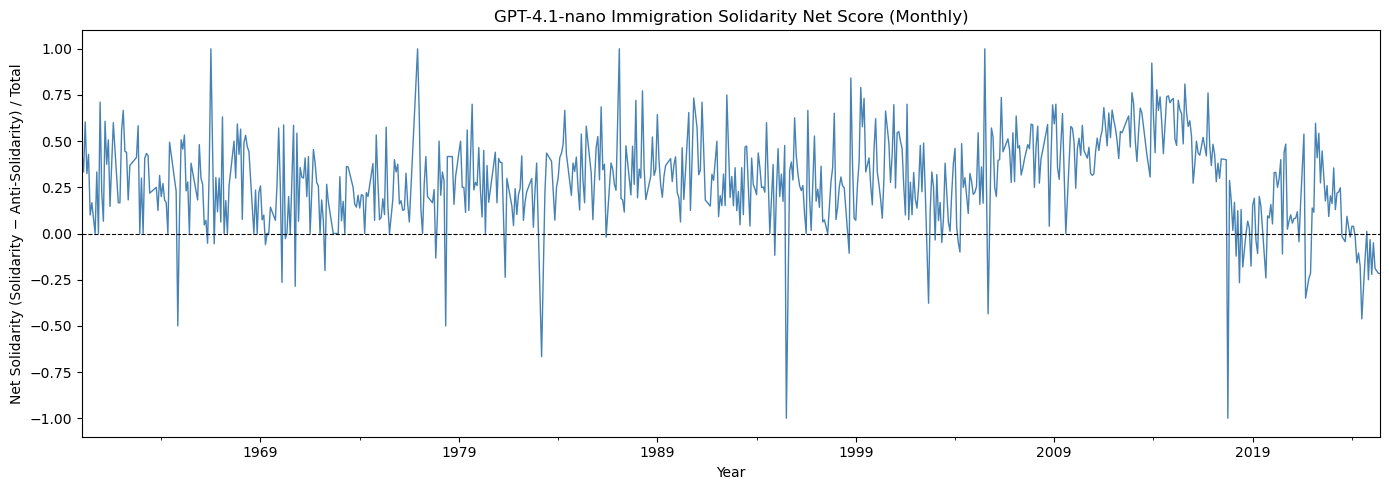

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
monthly_net.plot(ax=ax, color="steelblue", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("GPT-4.1-nano Immigration Solidarity Net Score (Monthly)")
ax.set_xlabel("Year")
ax.set_ylabel("Net Solidarity (Solidarity − Anti-Solidarity) / Total")
plt.tight_layout()
#plt.savefig("gpt_sentiment_monthly.png", dpi=150)
plt.show()

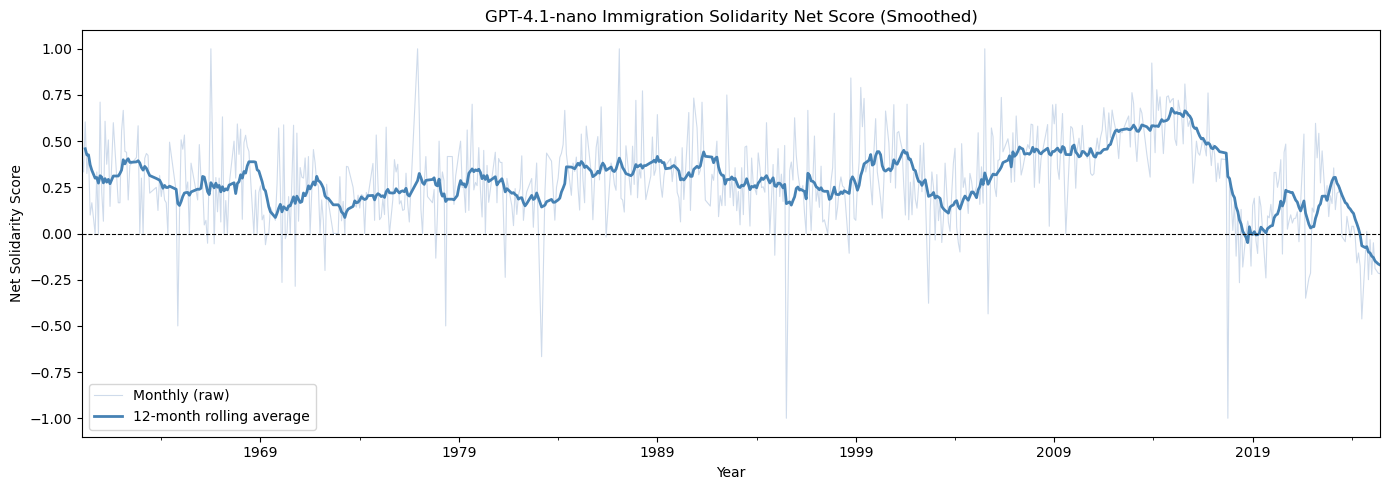

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
monthly_net.plot(ax=ax, color="lightsteelblue", linewidth=0.8, alpha=0.6, label="Monthly (raw)")
monthly_net.rolling(window=12, min_periods=3).mean().plot(
    ax=ax, color="steelblue", linewidth=2, label="12-month rolling average"
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("GPT-4.1-nano Immigration Solidarity Net Score (Smoothed)")
ax.set_xlabel("Year")
ax.set_ylabel("Net Solidarity Score")
ax.legend()
plt.tight_layout()
#plt.savefig("gpt_sentiment_smoothed.png", dpi=150)
plt.show()

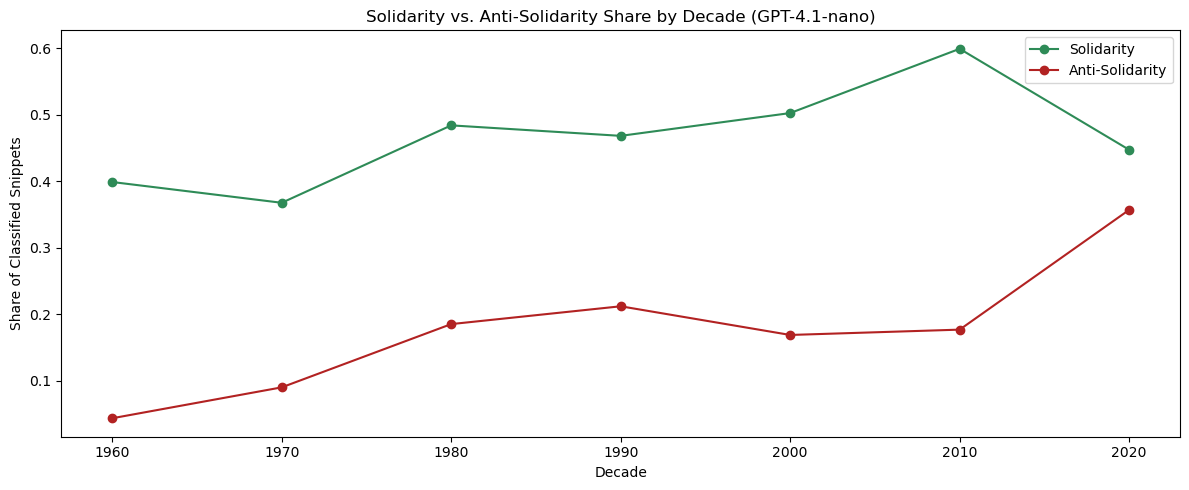

In [6]:
# decade_trend already computed in Step 8 — proportions of SOLIDARITY/ANTI-SOLIDARITY/MIXED/NONE per decade
fig, ax = plt.subplots(figsize=(12, 5))

decade_solidarity = decade_trend.get("SOLIDARITY", 0)
decade_antisolidarity = decade_trend.get("ANTI-SOLIDARITY", 0)

ax.plot(decade_trend.index, decade_solidarity, marker="o", color="seagreen", label="Solidarity")
ax.plot(decade_trend.index, decade_antisolidarity, marker="o", color="firebrick", label="Anti-Solidarity")
ax.set_title("Solidarity vs. Anti-Solidarity Share by Decade (GPT-4.1-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of Classified Snippets")
ax.legend()
plt.tight_layout()
#plt.savefig("gpt_decade_trend.png", dpi=150)
plt.show()

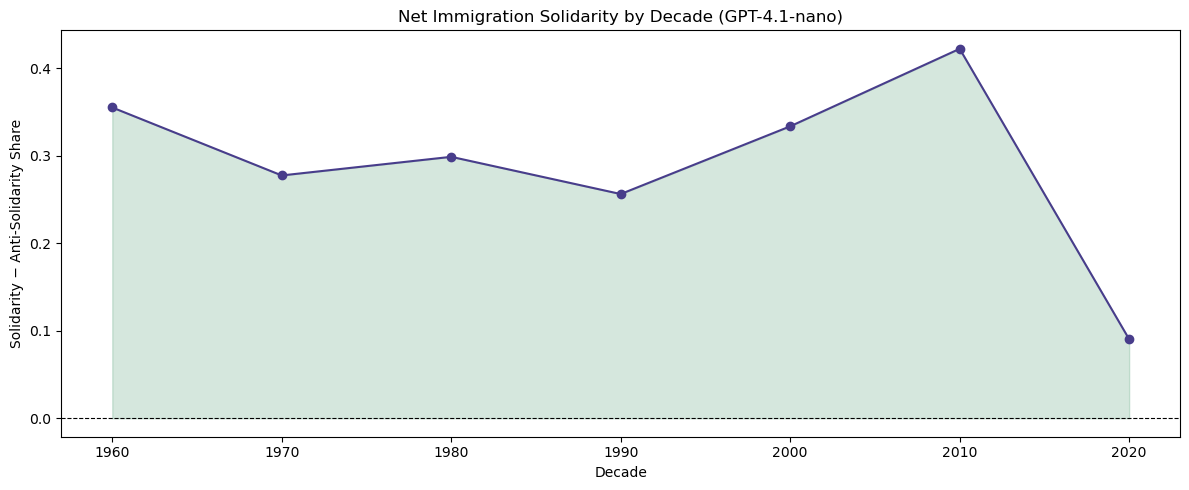

In [ ]:
decade_net = decade_solidarity - decade_antisolidarity

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(decade_net.index, decade_net.values, marker="o", color="darkslateblue")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(decade_net.index, decade_net.values, 0,
                 where=(decade_net.values >= 0), color="seagreen", alpha=0.2)
ax.fill_between(decade_net.index, decade_net.values, 0,
                 where=(decade_net.values < 0), color="firebrick", alpha=0.2)
ax.set_title("Net Immigration Solidarity by Decade (GPT-4.1-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Solidarity − Anti-Solidarity Share")
plt.tight_layout()
#plt.savefig("gpt_decade_net.png", dpi=150)
plt.show()

### SOLIDARITY SUBTYPE COMPOSITION BY DECADE (GPT-4.1-nano)

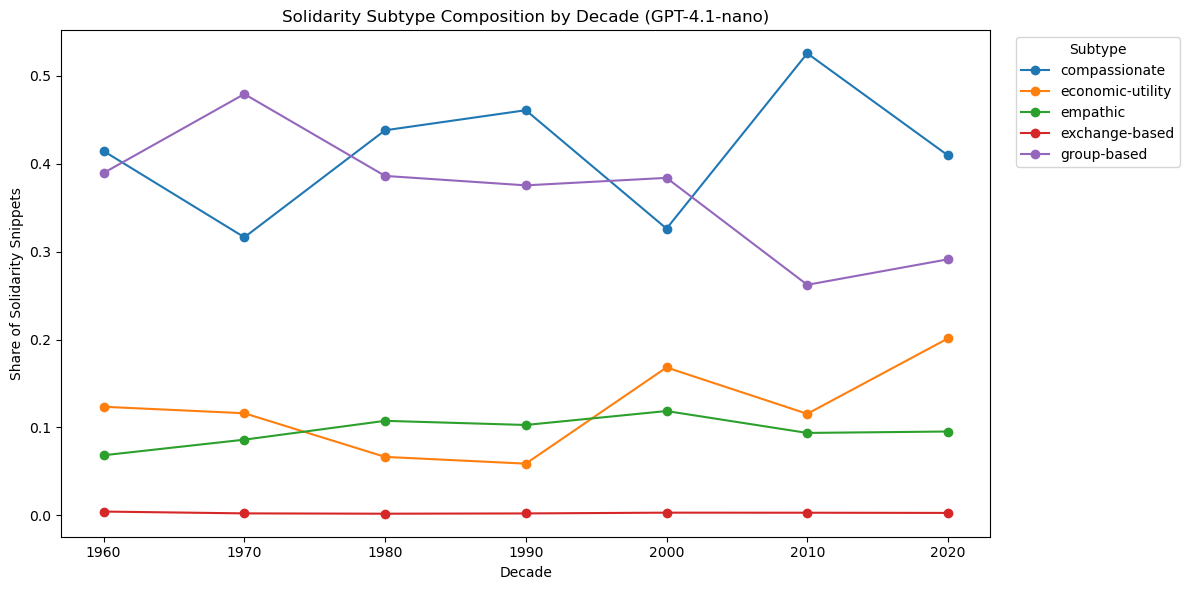

In [7]:
sol_subtype_trend = (
    ann_df[ann_df["high_level"] == "SOLIDARITY"]
    .groupby(["decade", "subtype"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)

fig, ax = plt.subplots(figsize=(12, 6))
sol_subtype_trend.plot(ax=ax, marker="o")
ax.set_title("Solidarity Subtype Composition by Decade (GPT-4.1-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of Solidarity Snippets")
ax.legend(title="Subtype", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
#plt.savefig("gpt_solidarity_subtypes.png", dpi=150)
plt.show()

### ANTI-SOLIDARITY SUBTYPE COMPOSITION BY DECADE (GPT-4.1-nano)

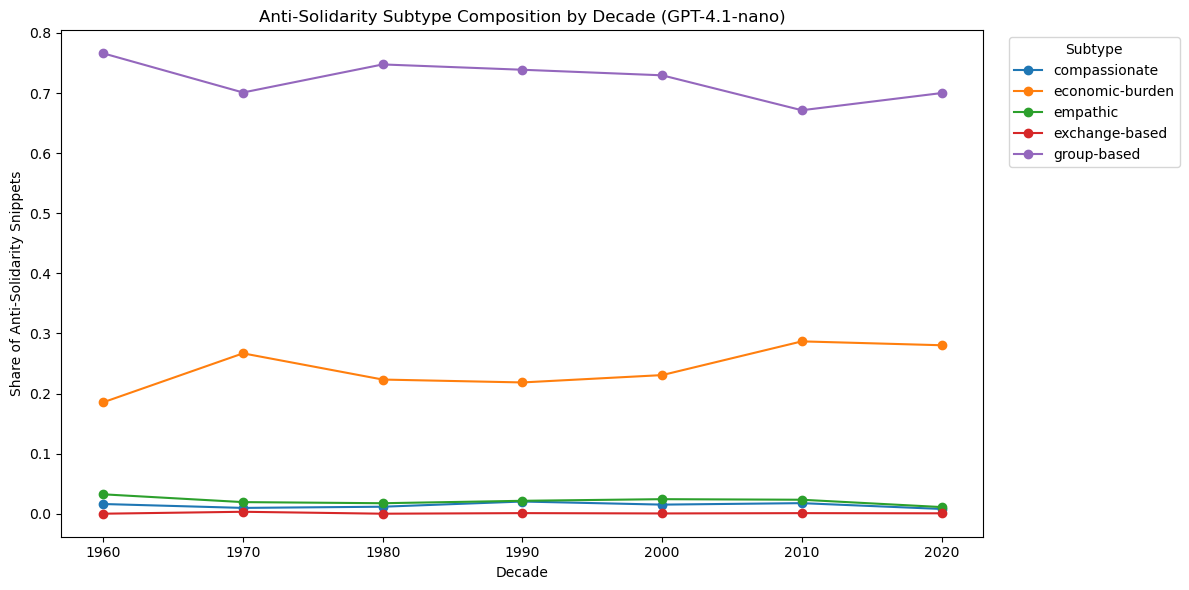

In [8]:
anti_subtype_trend = (
    ann_df[ann_df["high_level"] == "ANTI-SOLIDARITY"]
    .groupby(["decade", "subtype"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)

fig, ax = plt.subplots(figsize=(12, 6))
anti_subtype_trend.plot(ax=ax, marker="o")
ax.set_title("Anti-Solidarity Subtype Composition by Decade (GPT-4.1-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of Anti-Solidarity Snippets")
ax.legend(title="Subtype", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
#plt.savefig("gpt_antisolidarity_subtypes.png", dpi=150)
plt.show()

### GOVERNMENT VS. OPPOSITION — MONTHLY NET SOLIDARITY TREND

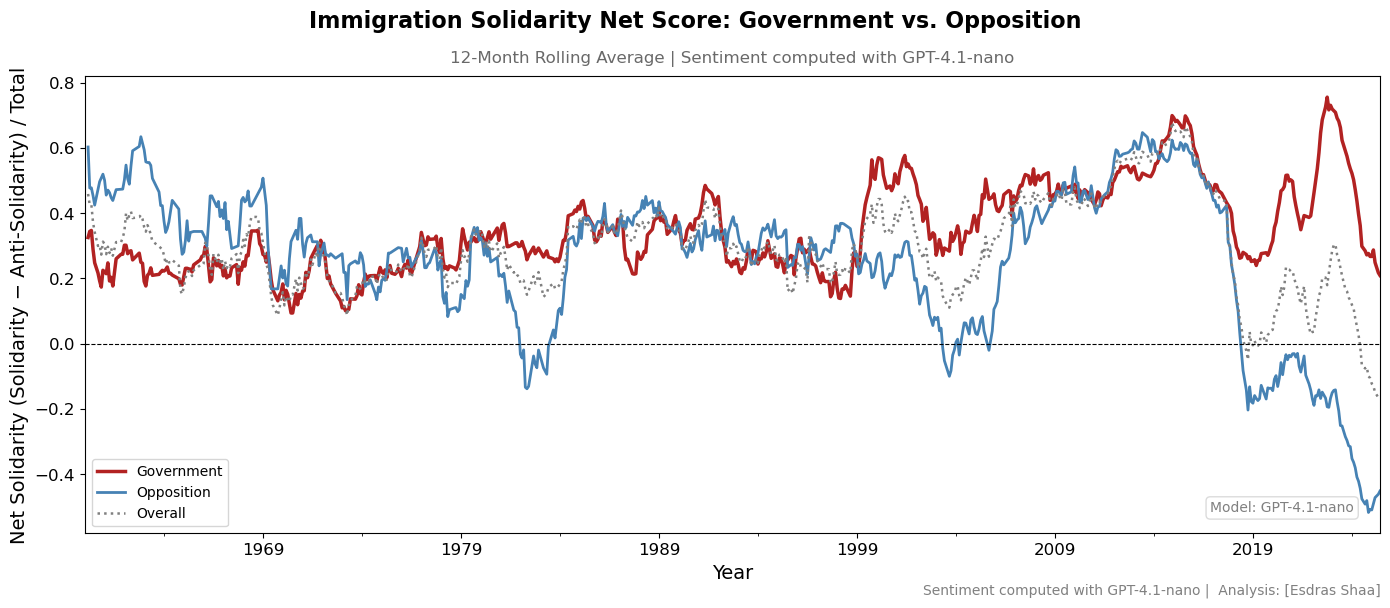

In [9]:

ann_df["month"] = ann_df["date"].dt.to_period("M")

def compute_monthly_net(df_subset: pd.DataFrame) -> pd.Series:
    counts = df_subset.groupby(["month", "high_level"]).size().unstack(fill_value=0)
    net = (counts.get("SOLIDARITY", 0) - counts.get("ANTI-SOLIDARITY", 0)) / counts.sum(axis=1)
    return net

gov_net = compute_monthly_net(ann_df[ann_df['governing_party'] == 1.0])
opp_net = compute_monthly_net(ann_df[ann_df["governing_party"] == 0.0])

fig, ax = plt.subplots(figsize=(14, 6))
gov_net.rolling(window=12, min_periods=3).mean().plot(ax=ax, color="firebrick", linewidth=2.5, label="Government")
opp_net.rolling(window=12, min_periods=3).mean().plot(ax=ax, color="steelblue", linewidth=2, label="Opposition")
monthly_net.rolling(window=12, min_periods=3).mean().plot(
    ax=ax, color="gray", linewidth=1.8, label="Overall", linestyle=":"
)


ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# Main Title & Subtitle mentioning Doc2Vec
plt.suptitle(
    "Immigration Solidarity Net Score: Government vs. Opposition",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
ax.set_title(
    "12-Month Rolling Average | Sentiment computed with GPT-4.1-nano",
    fontsize=12,
    color="dimgray",
    pad=10,
)

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Net Sentiment Score", fontsize=14)

# Tick labels
ax.tick_params(axis="both", which="major", labelsize=12)

# Legend font size
ax.legend(fontsize=12, loc="upper left")


ax.text(
    0.98,
    0.04,
    "Model: GPT-4.1-nano",
    transform=ax.transAxes,
    fontsize=10,
    color="gray",
    ha="right",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="lightgray",
        alpha=0.8,
    ),
)


ax.set_xlabel("Year")
ax.set_ylabel("Net Solidarity (Solidarity − Anti-Solidarity) / Total")
ax.legend()
fig.text(
    0.99, 0.005,
    "Sentiment computed with GPT-4.1-nano |  Analysis: [Esdras Shaa]",
    ha="right", fontsize=10, color="gray"
)

plt.tight_layout()
#plt.savefig("gov_vs_opposition_monthly.png", dpi=150)
plt.show()

In [11]:
# Create complete PeriodIndex range
full_period_range = pd.period_range(
    start=gov_net.index.min(), end=gov_net.index.max(), freq="M"
)

# Reindex using periods directly
gov_net_complete = gov_net.reindex(full_period_range)
gov_net_filled = gov_net_complete.interpolate(method="linear")

In [12]:
# Create complete PeriodIndex range
full_period_range = pd.period_range(
    start=gov_net.index.min(), end=gov_net.index.max(), freq="M"
)

# Reindex using periods directly
opp_net_complete = opp_net.reindex(full_period_range)
opp_net_filled = opp_net_complete.interpolate(method="linear")

In [13]:
# Create complete PeriodIndex range
full_period_range = pd.period_range(
    start=gov_net.index.min(), end=gov_net.index.max(), freq="M"
)

# Reindex using periods directly
monthly_net_complete = monthly_net.reindex(full_period_range)
monthly_net_filled = monthly_net_complete.interpolate(method="linear")

### ASSEMBLE & EXPORT MONTHLY GPT SENTIMENT SERIES FOR VAR 

In [14]:
gov_net_filled.name = "gpt_sentiment_government"
opp_net_filled.name = "gpt_sentiment_opposition"
monthly_net_filled.name = "gtp_overall_sentiment"

sent_df = pd.concat([gov_net_filled, opp_net_filled, monthly_net_filled], axis=1)


sent_df = sent_df.reset_index().rename(columns={"index": "month"})


sent_df["month"] = sent_df["month"].astype(str)
sent_df["month"] = pd.to_datetime(sent_df["month"], format="%Y-%m")
sent_df = sent_df.sort_values("month")

sent_df.to_csv("./DATA/GptSentimentMonthlyVargptNano.csv", index=False)

### COMPASSIONATE SUBTYPE SHARE BY PARTY (GPT-4.1-nano)

In [15]:
parties = [
    'Cabinet',
    'FDP',
    'CDU/CSU',
    'SPD',
   # 'DP',
   # 'fraktionslos',
    'GRÜNE',
    'PDS',
    'LINKE',
    'AfD',
   # 'SPDCDU/CSU',
    'BSW'
]
ann_df = ann_df[ann_df["party"].isin(parties)]

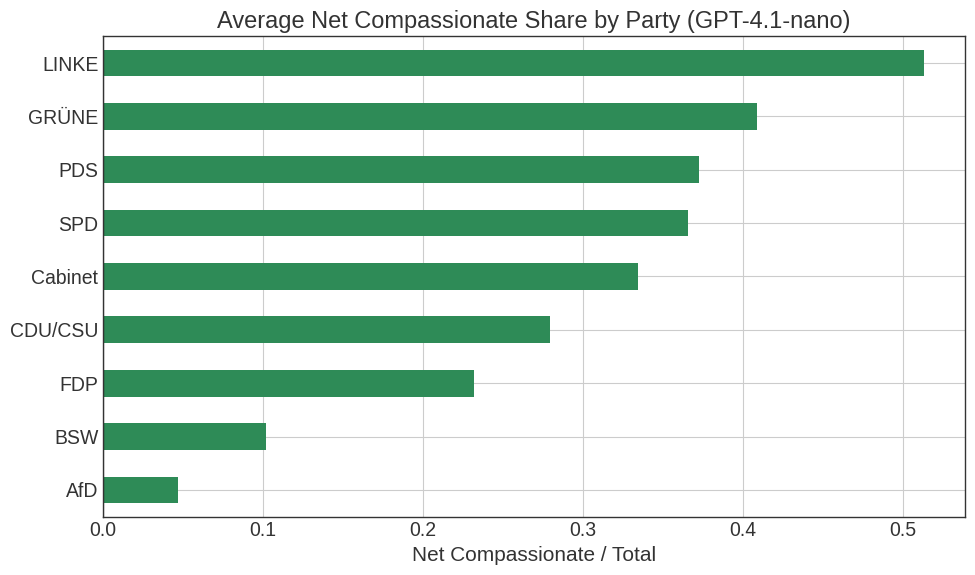

In [27]:
# Increase font sizes globally for publication quality
plt.rcParams.update(
    {
        "font.size": 15,
        "axes.titlesize": 17,
        "axes.labelsize": 15,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
)


def compute_party_net(df_subset: pd.DataFrame) -> pd.Series:
  counts = df_subset.groupby(["party", "subtype"]).size().unstack(fill_value=0)
  net = counts.get("compassionate", 0) / counts.sum(axis=1)
  return net.sort_values()


party_net = compute_party_net(ann_df)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["firebrick" if v < 0 else "seagreen" for v in party_net.values]
party_net.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Average Net Compassionate Share by Party (GPT-4.1-nano)")
ax.set_xlabel("Net Compassionate / Total")
ax.set_ylabel("")
plt.tight_layout()
# plt.savefig("party_net_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

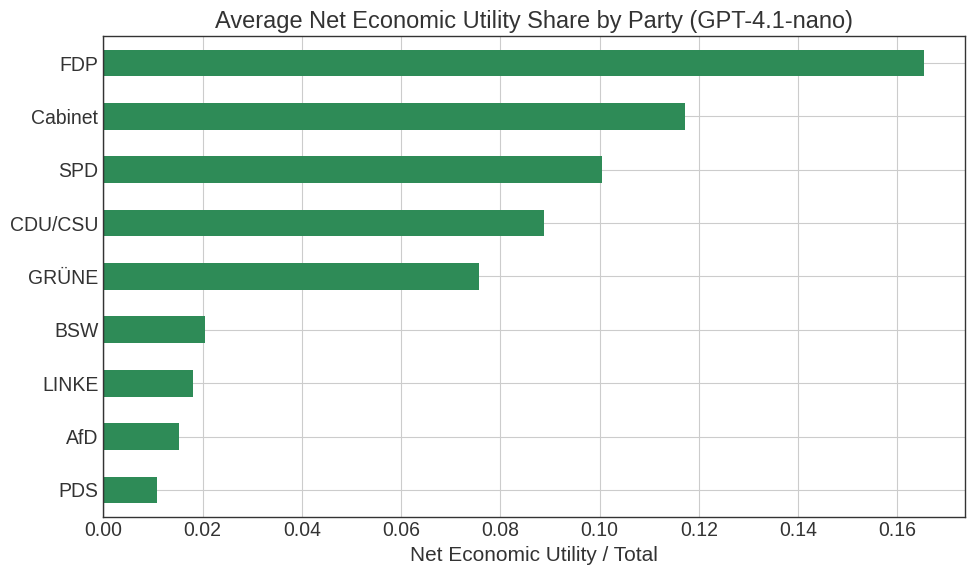

In [28]:
def compute_party_net(df_subset: pd.DataFrame) -> pd.Series:
  counts = df_subset.groupby(["party", "subtype"]).size().unstack(fill_value=0)
  net = counts.get("economic-utility", 0) / counts.sum(axis=1)
  return net.sort_values()


party_net = compute_party_net(ann_df)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["firebrick" if v < 0 else "seagreen" for v in party_net.values]
party_net.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Average Net Economic Utility Share by Party (GPT-4.1-nano)")
ax.set_xlabel("Net Economic Utility / Total")
ax.set_ylabel("")
plt.tight_layout()
# plt.savefig("party_net_economic_utility.png", dpi=300, bbox_inches="tight")
plt.show()

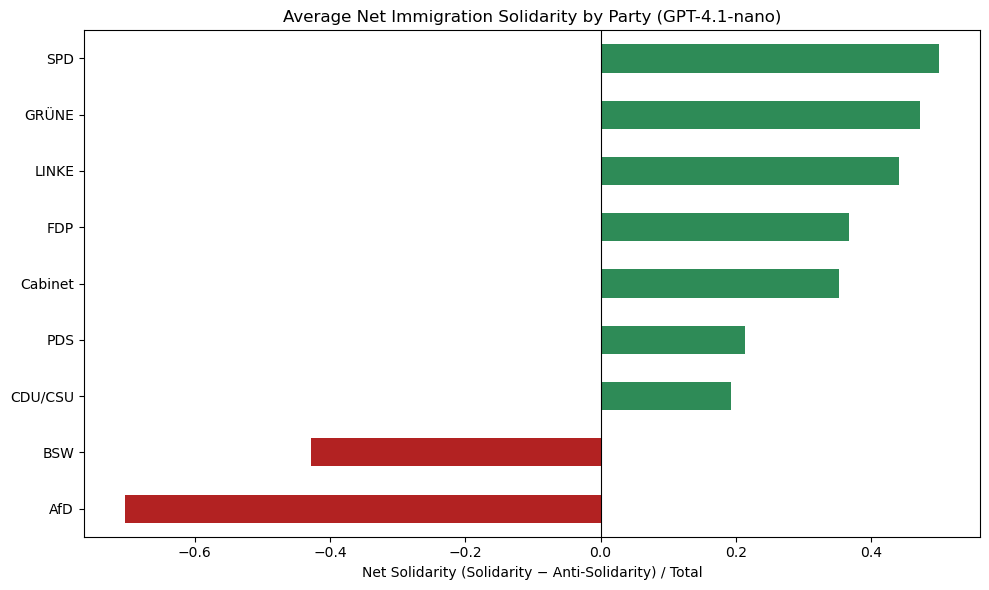

In [18]:
def compute_party_net(df_subset: pd.DataFrame) -> pd.Series:
    counts = df_subset.groupby(["party", "high_level"]).size().unstack(fill_value=0)
    net = (counts.get("SOLIDARITY", 0) - counts.get("ANTI-SOLIDARITY", 0)) / counts.sum(axis=1)
    return net.sort_values()

party_net = compute_party_net(ann_df)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["firebrick" if v < 0 else "seagreen" for v in party_net.values]
party_net.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Average Net Immigration Solidarity by Party (GPT-4.1-nano)")
ax.set_xlabel("Net Solidarity (Solidarity − Anti-Solidarity) / Total")
ax.set_ylabel("")
plt.tight_layout()
#plt.savefig("party_net_sentiment.png", dpi=150)
plt.show()

### GPT-4.1-nano SENTIMENT ANALYSIS — COMBINED DASHBOARD

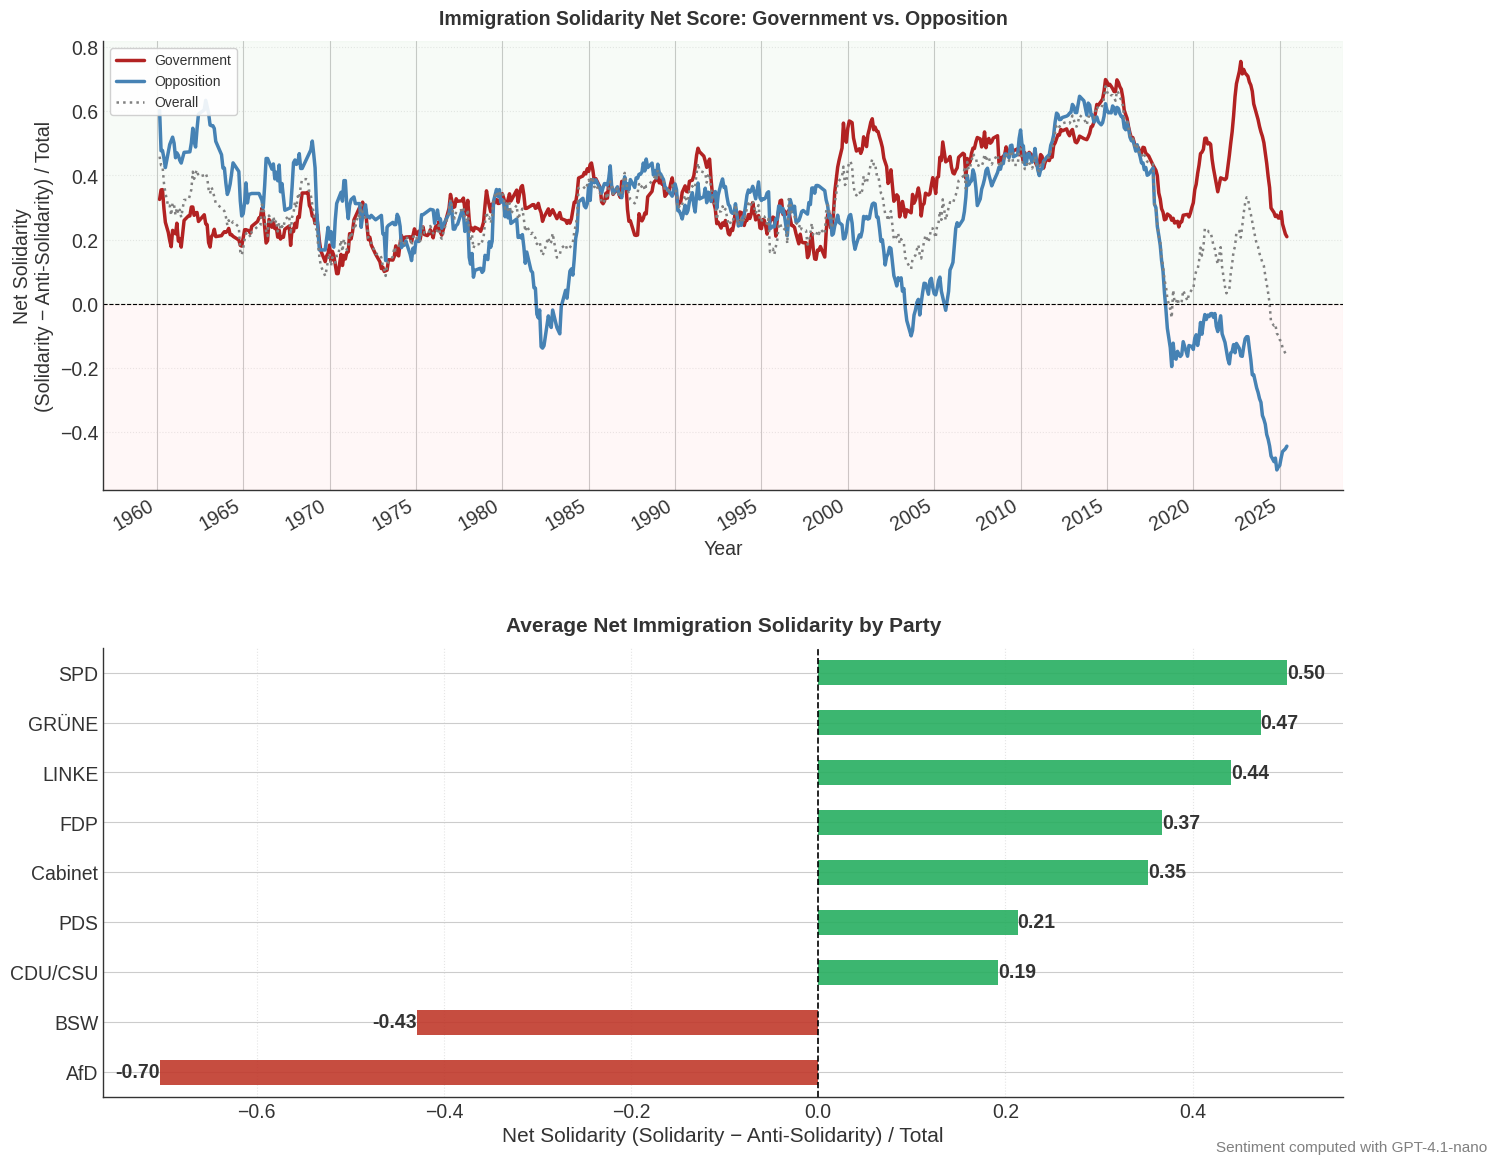

In [19]:

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.labelcolor"] = "#333333"
plt.rcParams["text.color"] = "#333333"
plt.rcParams["xtick.color"] = "#333333"
plt.rcParams["ytick.color"] = "#333333"



ann_df["month"] = ann_df["date"].dt.to_period("M")



def compute_monthly_net(df_subset: pd.DataFrame) -> pd.Series:
    counts = df_subset.groupby(["month", "high_level"]).size().unstack(fill_value=0)
    net = (counts.get("SOLIDARITY", 0) - counts.get("ANTI-SOLIDARITY", 0)) / counts.sum(axis=1)
    net.index = net.index.to_timestamp()  # convert PeriodIndex -> DatetimeIndex
    return net


def compute_party_net(df_subset: pd.DataFrame) -> pd.Series:
    counts = df_subset.groupby(["party", "high_level"]).size().unstack(fill_value=0)
    net = (counts.get("SOLIDARITY", 0) - counts.get("ANTI-SOLIDARITY", 0)) / counts.sum(axis=1)
    return net.sort_values()



gov_net     = compute_monthly_net(ann_df[ann_df["governing_party"] == 1.0])
opp_net     = compute_monthly_net(ann_df[ann_df["governing_party"] == 0.0])
overall_net = compute_monthly_net(ann_df)
party_net   = compute_party_net(ann_df)



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))



gov_net.rolling(window=12, min_periods=3).mean().plot(
    ax=ax1, color="firebrick", linewidth=2.5, label="Government", x_compat=True
)
opp_net.rolling(window=12, min_periods=3).mean().plot(
    ax=ax1, color="steelblue", linewidth=2.5, label="Opposition", x_compat=True
)
overall_net.rolling(window=12, min_periods=3).mean().plot(
    ax=ax1, color="gray", linewidth=1.8, linestyle=":", label="Overall", x_compat=True
)


ymin, ymax = ax1.get_ylim()
ax1.axhspan(0, ymax, color="green", alpha=0.03)
ax1.axhspan(ymin, 0, color="red", alpha=0.03)
ax1.set_ylim(ymin, ymax)

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.grid(axis="y", linestyle=":", alpha=0.4)

ax1.set_title(
    "Immigration Solidarity Net Score: Government vs. Opposition",
    fontsize=14, fontweight="bold", pad=12
)
ax1.set_xlabel("Year", fontsize=14)
ax1.set_ylabel("Net Solidarity\n(Solidarity − Anti-Solidarity) / Total", fontsize=14)
ax1.tick_params(axis="both", labelsize=14)
ax1.legend(fontsize=10, loc="upper left", frameon=True, framealpha=0.9)


ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))



colors = ["#c0392b" if val < 0 else "#27ae60" for val in party_net.values]
party_net.plot(kind="barh", color=colors, ax=ax2, alpha=0.9)

# Value labels at the end of each bar
for i, v in enumerate(party_net.values):
    ax2.text(
        v, i, f"{v:.2f}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=14,
        color="#333333",
        fontweight="bold",
    )

ax2.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax2.grid(axis="x", linestyle=":", alpha=0.5)

ax2.set_title(
    "Average Net Immigration Solidarity by Party",
    fontsize=15, fontweight="bold", pad=12
)
ax2.set_xlabel("Net Solidarity (Solidarity − Anti-Solidarity) / Total", fontsize=15)
ax2.set_ylabel("")
ax2.tick_params(axis="both", labelsize=14)



for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)



# fig.suptitle(
#     "How Do German Political Parties Talk About Immigration? (GPT-4.1-nano)",
#     fontsize=17, fontweight="bold", y=0.995
# )

plt.subplots_adjust(hspace=0.35, top=0.93, bottom=0.05)

fig.text(
    0.99, 0.005,
    "Sentiment computed with GPT-4.1-nano",
    ha="right", fontsize=11, color="gray"
)

plt.show()

### IMMIGRATION STANCE DISTRIBUTION BY PARTY (GPT-4.1-nano)

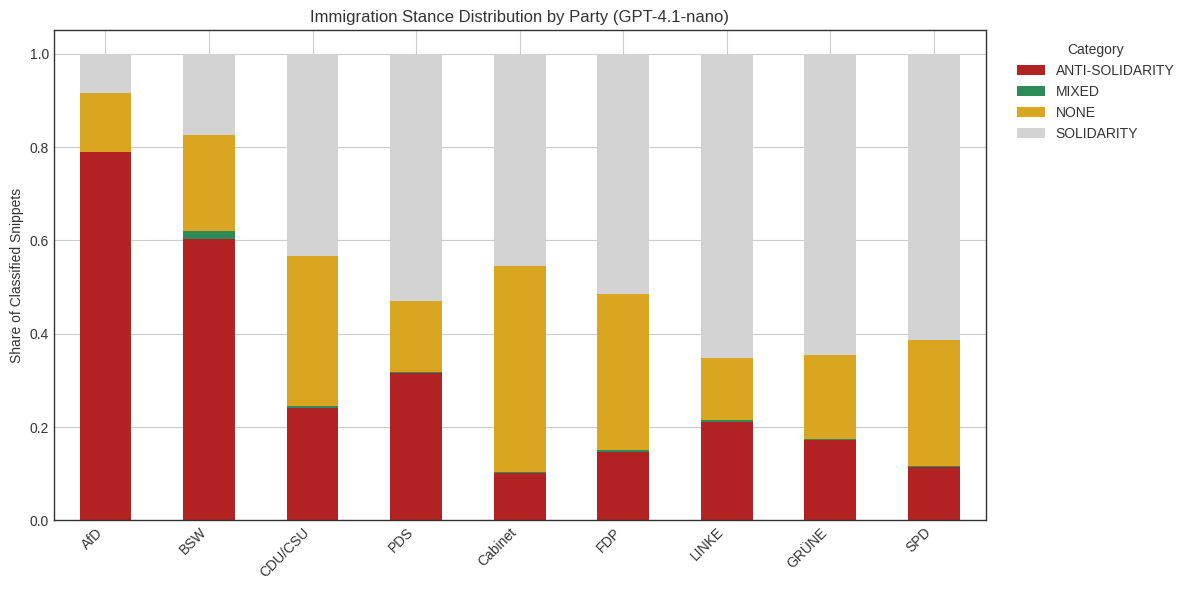

In [20]:
party_dist = (
    ann_df.groupby(["party", "high_level"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)

# order parties by net solidarity for a readable left-to-right gradient
party_order = party_net.index.tolist()
party_dist = party_dist.reindex(party_order)

fig, ax = plt.subplots(figsize=(12, 6))
party_dist.plot(kind="bar", stacked=True, ax=ax,
                  color=["firebrick", "seagreen", "goldenrod", "lightgray"])
ax.set_title("Immigration Stance Distribution by Party (GPT-4.1-nano)")
ax.set_ylabel("Share of Classified Snippets")
ax.set_xlabel("")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig("party_distribution.png", dpi=150)
plt.show()

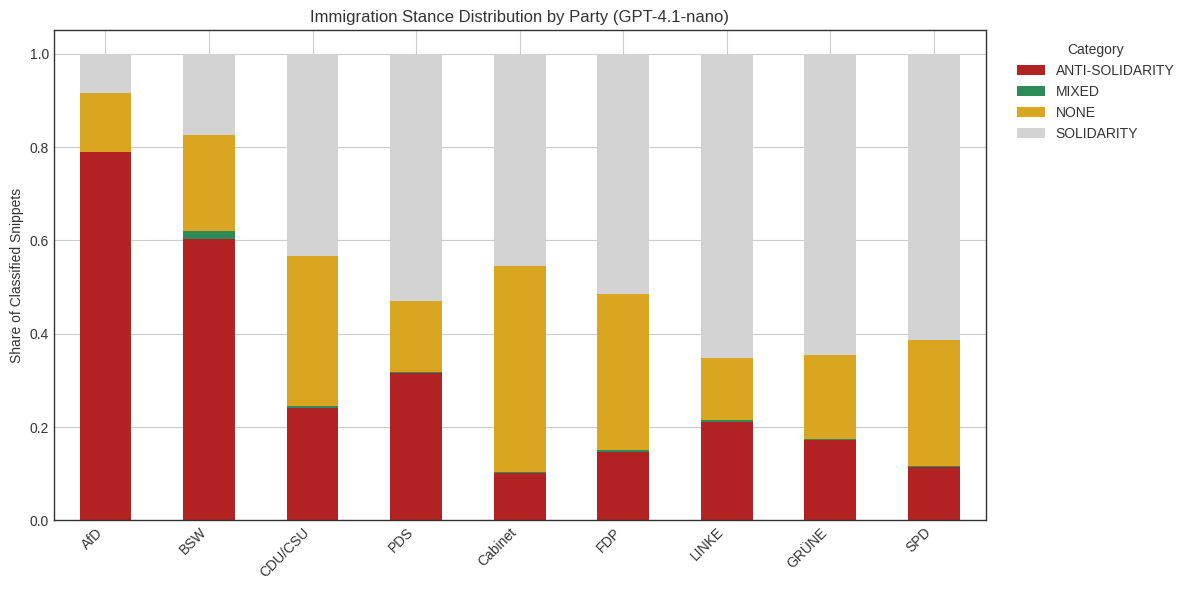

In [21]:
party_dist = (
    ann_df.groupby(["party", "high_level"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)

# order parties by net solidarity for a readable left-to-right gradient
party_order = party_net.index.tolist()
party_dist = party_dist.reindex(party_order)

fig, ax = plt.subplots(figsize=(12, 6))
party_dist.plot(kind="bar", stacked=True, ax=ax,
                  color=["firebrick", "seagreen", "goldenrod", "lightgray"])
ax.set_title("Immigration Stance Distribution by Party (GPT-4.1-nano)")
ax.set_ylabel("Share of Classified Snippets")
ax.set_xlabel("")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("party_distribution.png", dpi=150)
plt.show()

/tmp/ipykernel_726408/3150000512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ann_df["decade"] = (ann_df["date"].dt.year // 10) * 10


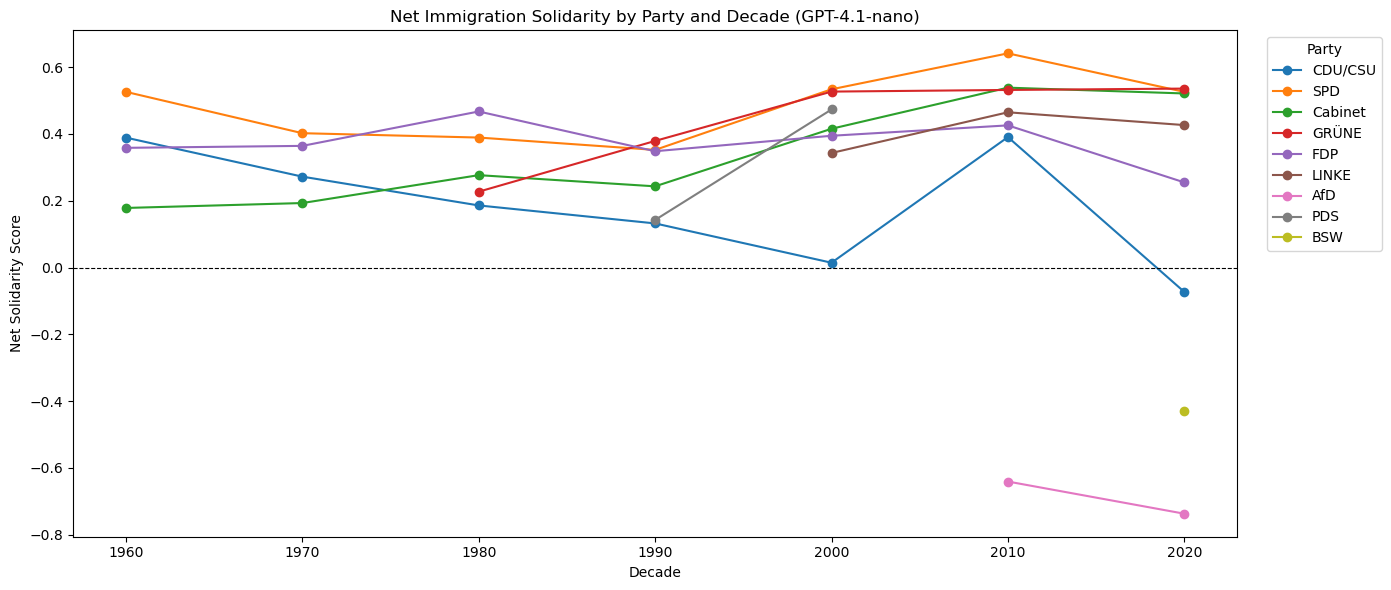

In [96]:
ann_df["decade"] = (ann_df["date"].dt.year // 10) * 10

party_decade_counts = (
    ann_df.groupby(["decade", "party", "high_level"]).size()
    .unstack(fill_value=0)
)
party_decade_net = (
    (party_decade_counts.get("SOLIDARITY", 0) - party_decade_counts.get("ANTI-SOLIDARITY", 0))
    / party_decade_counts.sum(axis=1)
).unstack("party")

# focus on parties with enough data to be meaningful — drop very sparse ones
min_snippets_per_party = 30
party_counts_total = ann_df["party"].value_counts()
main_parties = party_counts_total[party_counts_total >= min_snippets_per_party].index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
party_decade_net[main_parties].plot(ax=ax, marker="o")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Net Immigration Solidarity by Party and Decade (GPT-4.1-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Net Solidarity Score")
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("party_decade_trend.png", dpi=150)
plt.show()

### NET SOLIDARITY HEATMAP — PARTY × DECADE (GPT-4.1-nano)

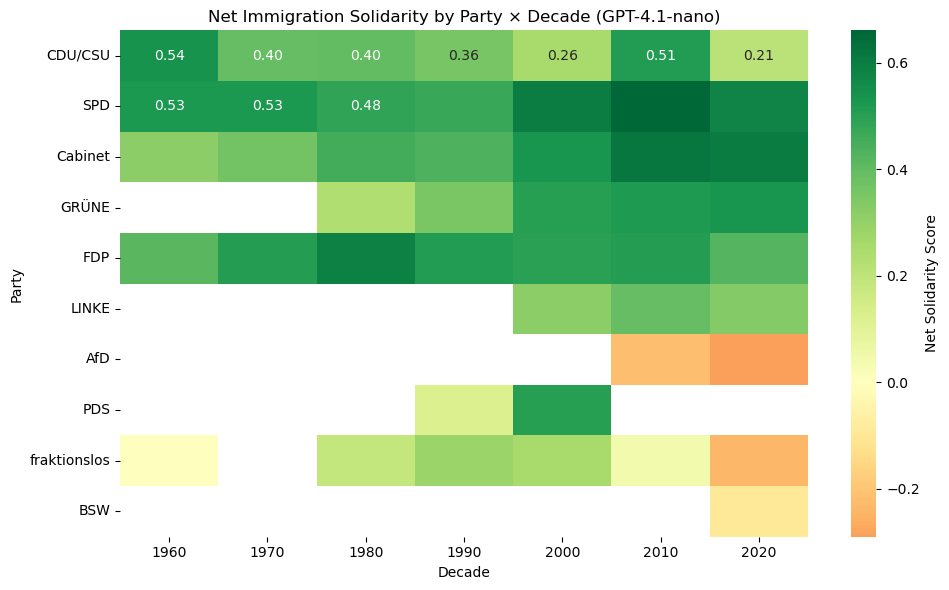

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    party_decade_net[main_parties].T,
    cmap="RdYlGn", center=0, annot=True, fmt=".2f",
    cbar_kws={"label": "Net Solidarity Score"}, ax=ax,
)
ax.set_title("Net Immigration Solidarity by Party × Decade (GPT-4.1-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Party")
plt.tight_layout()
plt.savefig("party_decade_heatmap.png", dpi=150)
plt.show()